In [1]:
# %% [markdown]
# # 05 — Inventory Optimization (Safety Stock + EOQ)
# ## RetailPulse — Zidio Development | March 2026


In [2]:
# %%[markdown]
# ## Imports & Setup

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

In [4]:
# %%[markdown]
# ## Load Processed Data

In [5]:
sales = pd.read_parquet('../data/processed/sales_clean.parquet')
products = pd.read_parquet('../data/processed/products_clean.parquet')
print(f"Sales: {len(sales):,} rows")
print(f"Products: {len(products):,}")

Sales: 779,425 rows
Products: 5,314


In [6]:
# %%[markdown]
# ## InventoryOptimizer Class

In [7]:
class InventoryOptimizer:
    def __init__(self, service_level=0.95, lead_time_days=7, ordering_cost=50, 
                 holding_cost_pct=0.25, unit_cost=10):
        self.service_level = service_level
        self.lead_time_days = lead_time_days
        self.ordering_cost = ordering_cost
        self.holding_cost_pct = holding_cost_pct
        self.unit_cost = unit_cost
        self.z_score = norm.ppf(service_level)
    
    def compute_safety_stock(self, demand_std, lead_time=None):
        lt = lead_time or self.lead_time_days
        return self.z_score * demand_std * np.sqrt(lt)
    
    def compute_reorder_point(self, avg_daily_demand, demand_std, lead_time=None):
        lt = lead_time or self.lead_time_days
        ss = self.compute_safety_stock(demand_std, lt)
        return round(avg_daily_demand * lt + ss, 0), round(ss, 0)
    
    def compute_eoq(self, annual_demand):
        H = self.unit_cost * self.holding_cost_pct
        return round(np.sqrt((2 * annual_demand * self.ordering_cost) / H), 0)
    
    def generate_recommendations(self, df_products):
        recs = []
        for _, row in df_products.iterrows():
            rop, ss = self.compute_reorder_point(row['avg_daily_demand'], row['demand_std'])
            eoq = self.compute_eoq(row['annual_demand'])
            status = 'REORDER NOW' if row['current_stock'] <= rop else 'OK'
            recs.append({
                'product_id': row['product_id'],
                'Current_Stock': row['current_stock'],
                'Reorder_Point': rop,
                'Safety_Stock': ss,
                'EOQ': eoq,
                'Status': status,
                'Urgency': 'HIGH' if row['current_stock'] <= ss else 'NORMAL'
            })
        return pd.DataFrame(recs)

In [8]:
# %%[markdown]
# ## Compute Product-Level Demand

In [9]:
product_demand = sales.groupby('product_id').agg(
    avg_daily_demand=('quantity', lambda x: x.sum() / sales['date'].nunique()),
    demand_std=('quantity', 'std'),
    annual_demand=('quantity', 'sum'),
).reset_index()

# Add product names and mock current stock
product_demand = product_demand.merge(products[['product_id', 'category']], on='product_id', how='left')
np.random.seed(42)
product_demand['current_stock'] = np.random.randint(10, 500, len(product_demand))

print(f"Products with demand data: {len(product_demand):,}")
print(product_demand.describe())

Products with demand data: 4,631
        product_id  avg_daily_demand   demand_std  annual_demand  \
count  4631.000000       4631.000000  4507.000000    4631.000000   
mean   2316.000000          0.065645    37.343176    2270.341611   
std    1336.998878          0.164165   183.392715    5677.635283   
min       1.000000          0.000029     0.000000       1.000000   
25%    1158.500000          0.003296     4.522443     114.000000   
50%    2316.000000          0.017927    12.141445     620.000000   
75%    3473.500000          0.059910    26.080102    2072.000000   
max    4631.000000          3.041347  5272.997869  105185.000000   

       current_stock  
count    4631.000000  
mean      255.529691  
std       141.624263  
min        10.000000  
25%       134.000000  
50%       257.000000  
75%       380.000000  
max       499.000000  


In [10]:
# %%[markdown]
# ## Generate Recommendations

In [11]:
optimizer = InventoryOptimizer(service_level=0.95, lead_time_days=7)
recommendations = optimizer.generate_recommendations(product_demand.head(1000))

print(f"Recommendations generated: {len(recommendations)}")
reorder_now = recommendations[recommendations['Status'] == 'REORDER NOW']
print(f"Need reorder: {len(reorder_now)} products")
print(f"\nTop urgent items:")
print(recommendations[recommendations['Urgency'] == 'HIGH'].head(10))

Recommendations generated: 1000
Need reorder: 197 products

Top urgent items:
    product_id  Current_Stock  Reorder_Point  Safety_Stock     EOQ  \
0            1            112          273.0         271.0   582.0   
5            6             81           87.0          87.0   364.0   
7            8             30          208.0         207.0   394.0   
9           10            131          200.0         199.0   413.0   
11          12            224          609.0         607.0   627.0   
12          13            340          683.0         675.0  1281.0   
14          15             97          258.0         258.0   354.0   
16          17            109          138.0         138.0   390.0   
18          19            161         3008.0        3002.0  1084.0   
19          20            140          173.0         173.0   251.0   

         Status Urgency  
0   REORDER NOW    HIGH  
5   REORDER NOW    HIGH  
7   REORDER NOW    HIGH  
9   REORDER NOW    HIGH  
11  REORDER NOW    HI

In [12]:
# %%[markdown]
# ## Visualize Stock Status

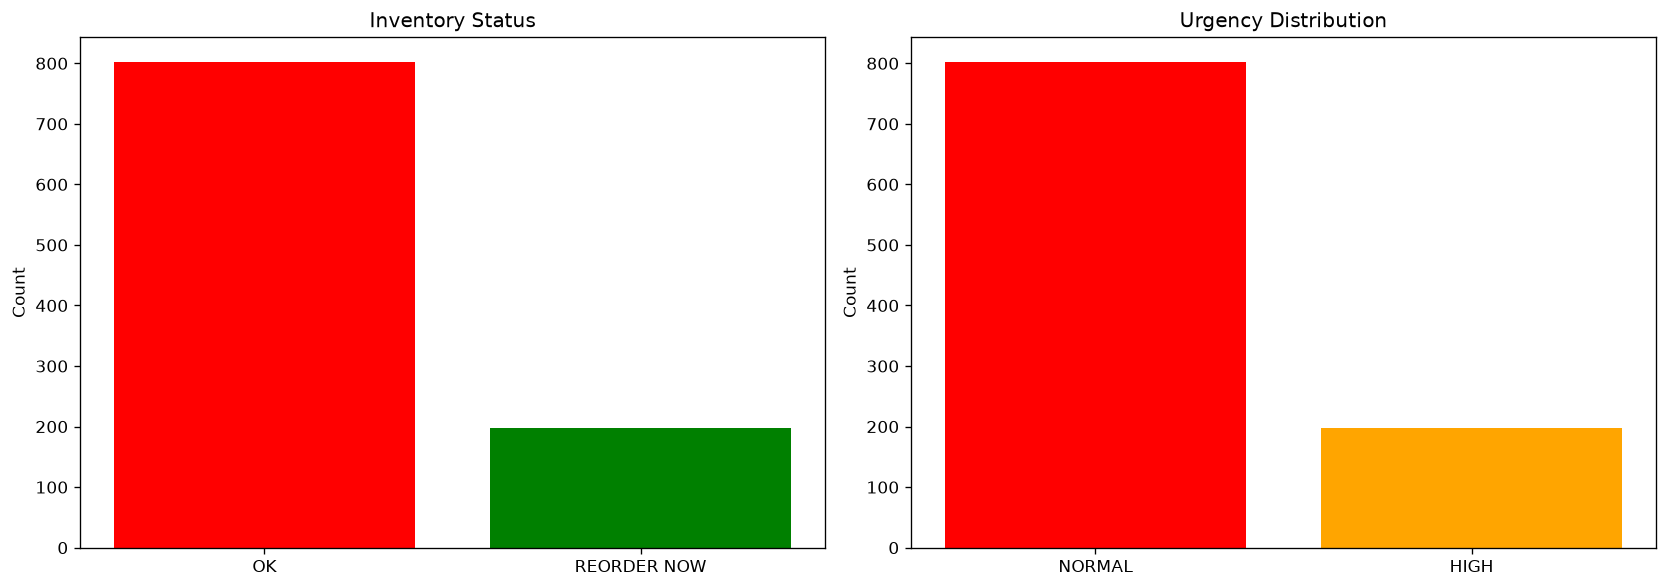

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
status_counts = recommendations['Status'].value_counts()
axes[0].bar(status_counts.index, status_counts.values, color=['red', 'green'])
axes[0].set_title('Inventory Status')
axes[0].set_ylabel('Count')

urgency_counts = recommendations['Urgency'].value_counts()
axes[1].bar(urgency_counts.index, urgency_counts.values, color=['red', 'orange'])
axes[1].set_title('Urgency Distribution')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/inventory_status.png', bbox_inches='tight')
plt.show()

In [14]:
# %%[markdown]
# ## Save Recommendations

In [15]:
recommendations.to_csv('../data/processed/inventory_recommendations.csv', index=False)
print(f"Saved inventory_recommendations.csv with {len(recommendations)} recommendations")
product_demand.to_csv('../data/processed/product_demand.csv', index=False)

print(f"\nInventory Optimization Summary:")
print(f"  Service Level: {optimizer.service_level*100:.0f}%")
print(f"  Lead Time: {optimizer.lead_time_days} days")
print(f"  Products Analyzed: {len(recommendations)}")
print(f"  Reorder Required: {len(reorder_now)} ({len(reorder_now)/len(recommendations)*100:.1f}%)")

Saved inventory_recommendations.csv with 1000 recommendations

Inventory Optimization Summary:
  Service Level: 95%
  Lead Time: 7 days
  Products Analyzed: 1000
  Reorder Required: 197 (19.7%)
